# Assignment 3 — Final Project: Toronto Public Library Data Visualizations

**Dataset(s):** City of Toronto Open Data Portal — Toronto Public Library
- *Branch General Information* — https://open.toronto.ca/dataset/library-branch-general-information/
- *Visits* — https://open.toronto.ca/dataset/library-visits/

This notebook fetches the data **live** from the City of Toronto CKAN API so the result is fully reproducible: anyone running it pulls the same source data. Two distinct visualizations are produced in Python (matplotlib), exported as high-resolution PNGs.

> **NOTE TO SELF (Nico):** the written reflection questions (audience, message, impact, underwater labour, etc.) live in the two companion Markdown files. The scaffold there has prompts — fill them in your own voice. The rubric grades *your* reasoning on those.

---

## 0. Setup

In [1]:
import requests          # to call the CKAN API
import pandas as pd        # data wrangling
import numpy as np         # numerics
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Folder for exported figures
OUT = Path("figures")
OUT.mkdir(exist_ok=True)

# CKAN base URL for the City of Toronto Open Data portal
CKAN = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

## 1. Pull the data live from CKAN

The City of Toronto uses CKAN. The pattern is:
1. `package_show` to get a dataset's resources,
2. find the active **datastore** resource,
3. pull its records via `datastore_search` (paginated).

The helper below does this for any dataset slug.

In [2]:
def get_ckan_records(package_id, ckan=CKAN, max_records=100000):
    """Return a DataFrame of all records from the first active datastore
    resource in a CKAN package. Comments explain each step for reproducibility."""
    # 1. Get package metadata (lists all resources/files in the dataset)
    pkg = requests.get(f"{ckan}/api/3/action/package_show",
                       params={"id": package_id}, timeout=60).json()
    resources = pkg["result"]["resources"]

    # 2. Pick the first resource that is loaded into CKAN's datastore (queryable)
    ds = next((r for r in resources if r.get("datastore_active")), None)
    if ds is None:
        raise RuntimeError(f"No active datastore resource in '{package_id}'.")

    # 3. Page through datastore_search until all rows are retrieved
    rows, offset, page = [], 0, 32000
    while True:
        resp = requests.get(f"{ckan}/api/3/action/datastore_search",
                            params={"id": ds["id"], "limit": page, "offset": offset},
                            timeout=60).json()
        recs = resp["result"]["records"]
        rows.extend(recs)
        if len(recs) < page or len(rows) >= max_records:
            break
        offset += page
    return pd.DataFrame(rows)

In [3]:
# Fetch both datasets. If you are offline or the API is down, see the fallback cell below.
USE_LIVE = True   # <-- set to False only if you cannot reach the API

if USE_LIVE:
    branches = get_ckan_records("library-branch-general-information")
    visits   = get_ckan_records("library-visits")
    print("branches:", branches.shape)
    print("visits:", visits.shape)
    display(branches.head())
    display(visits.head())

branches: (112, 29)
visits: (1233, 4)


,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,...,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear,PublicWashroom,Hours,geometry
0,1,AB,1,Albion,"1515 Albion Road, Toronto, ON, M9V 1B2",M9V 1B2,https://www.tpl.ca/albion,416-394-5170,32279,67,...,-79.5845,2.0,Mount Olive-Silverstone-Jamestown,1,1.0,Etobicoke North,1973.0,1,Mon 9 a.m. to 8:30 p.m.; Tue 9 a.m. to 8:30 p....,"{""coordinates"": [[-79.5845, 43.73999]], ""type""..."
1,2,ACD,1,Albert Campbell,"496 Birchmount Road, Toronto, ON, M1K 1N8",M1K 1N8,https://www.tpl.ca/albertcampbell,416-396-8890,28957,45,...,-79.26911,120.0,Clairlea-Birchmount,1,20.0,Scarborough Southwest,1971.0,1,Mon 9 a.m. to 8:30 p.m.; Tue 9 a.m. to 8:30 p....,"{""coordinates"": [[-79.26911, 43.70814]], ""type..."
2,3,AD,1,Alderwood,"2 Orianna Drive, Toronto, ON, M8W 4Y1",M8W 4Y1,https://www.tpl.ca/alderwood,416-394-5310,7341,shared,...,-79.54714,20.0,Alderwood,0,3.0,Etobicoke-Lakeshore,1999.0,None,Mon 10 a.m. to 8:30 p.m.; Tue 10 a.m. to 6 p.m...,"{""coordinates"": [[-79.54714, 43.60168]], ""type..."
3,4,AG,1,Agincourt,"155 Bonis Avenue, Toronto, ON, M1T 3W6",M1T 3W6,https://www.tpl.ca/agincourt,416-396-8943,27690,90,...,-79.29349,118.0,Tam O'Shanter-Sullivan,0,22.0,Scarborough-Agincourt,1991.0,1,Mon 9 a.m. to 8:30 p.m.; Tue 9 a.m. to 8:30 p....,"{""coordinates"": [[-79.29349, 43.78522]], ""type..."
4,5,AH,1,Armour Heights,"2140 Avenue Road, Toronto, ON, M5M 4M7",M5M 4M7,https://www.tpl.ca/armourheights,416-395-5430,2988,shared,...,-79.42178,39.0,Bedford Park-Nortown,0,8.0,Eglinton-Lawrence,1982.0,None,Mon 10 a.m. to 8:30 p.m.; Tue 12:30 p.m. to 8:...,"{""coordinates"": [[-79.42178, 43.73922]], ""type..."


,_id,Year,BranchCode,Visits
0,1,2012,AB,522309
1,2,2012,ACD,214076
2,3,2012,AD,88065
3,4,2012,AG,434320
4,5,2012,AH,67184


### Fallback (only if live fetch fails)
This builds a small **synthetic** stand-in with the same column names so you can see the notebook run. **Do not submit results from this cell** — re-run with `USE_LIVE = True` on a connected machine so your figures use real data. Delete this cell for your final submission if you fetched live.

In [4]:
if not USE_LIVE:
    rng = np.random.default_rng(613)
    codes = [f"B{i:02d}" for i in range(1, 31)]
    names = [f"Branch {i}" for i in range(1, 31)]
    branches = pd.DataFrame({
        "BranchCode": codes,
        "BranchName": names,
        "SquareFootage": rng.integers(2000, 90000, 30),
    })
    visits = pd.DataFrame({
        "Year": np.repeat([2022, 2023, 2024], 30),
        "BranchCode": codes * 3,
        "Visits": rng.integers(7000, 1200000, 90),
    })
    print("Using SYNTHETIC fallback data — not for submission.")

## 2. Clean and prepare

Comments document every decision (a reproducibility + accountability practice from the *Reproducible Data Visualization* deck). Column names from CKAN can shift slightly between refreshes, so we normalize defensively.

In [5]:
# Normalize column names to lowercase_snake for stable referencing
def snake(df):
    df = df.copy()
    df.columns = (df.columns.str.strip().str.replace(r"[ \-]+", "_", regex=True).str.lower())
    return df

branches = snake(branches)
visits   = snake(visits)
print("branch cols:", list(branches.columns))
print("visit cols: ", list(visits.columns))

branch cols: ['_id', 'branchcode', 'physicalbranch', 'branchname', 'address', 'postalcode', 'website', 'telephone', 'squarefootage', 'publicparking', 'kidsstop', 'leadingreading', 'clc', 'dih', 'teencouncil', 'youthhub', 'adultliteracyprogram', 'service_tier', 'lat', 'long', 'nbhdno', 'nbhdname', 'tplnia', 'wardno', 'wardname', 'presentsiteyear', 'publicwashroom', 'hours', 'geometry']
visit cols:  ['_id', 'year', 'branchcode', 'visits']


In [6]:
# --- Identify the columns we need (by name) ---
# The two datasets join on BRANCHCODE (the visits table has no branch name),
# so we resolve branchcode in both, plus branchname + squarefootage from branches.
def find_col(df, *keywords):
    for c in df.columns:
        if all(k in c for k in keywords):
            return c
    raise KeyError(f"No column matching {keywords} in {list(df.columns)}")

b_name = find_col(branches, "branchname")     # readable label for plots
b_code = find_col(branches, "branchcode")     # join key
b_sqft = find_col(branches, "square")         # square footage

v_code = find_col(visits, "branchcode")       # join key (visits has no name)
v_year = find_col(visits, "year")
v_visit = find_col(visits, "visit")

# Coerce numerics (API returns these as strings)
branches[b_sqft] = pd.to_numeric(branches[b_sqft], errors="coerce")
visits[v_visit] = pd.to_numeric(visits[v_visit], errors="coerce")
visits[v_year]  = pd.to_numeric(visits[v_year], errors="coerce")

print("Resolved columns:")
print("  branch name:", b_name, "| branch code:", b_code, "| sqft:", b_sqft)
print("  visit code:", v_code, "| year:", v_year, "| visits:", v_visit)

Resolved columns:
  branch name: branchname | branch code: branchcode | sqft: squarefootage
  visit code: branchcode | year: year | visits: visits


In [7]:
# Keep the most recent year of visit data for the per-branch comparison
latest_year = int(visits[v_year].max())
visits_latest = visits[visits[v_year] == latest_year][[v_code, v_visit]].dropna()

# Merge visits onto branch attributes USING BRANCHCODE (the shared key).
# This also brings in branchname so the plots can use readable labels.
merged = visits_latest.merge(
    branches[[b_code, b_name, b_sqft]],
    on=b_code, how="inner"
).dropna(subset=[b_sqft, v_visit])

print(f"Latest year of visit data: {latest_year}")
print("Merged rows (branches matched):", len(merged))
merged.head()

Latest year of visit data: 2023
Merged rows (branches matched): 99


,branchcode,visits,branchname,squarefootage
0,AB,250527,Albion,32279.0
1,ACD,136572,Albert Campbell,28957.0
2,AD,69595,Alderwood,7341.0
3,AG,138856,Agincourt,27690.0
4,AH,6913,Armour Heights,2988.0


## 3. Visualization 1 — Visits per square foot: which branches work hardest?

**Chart type:** horizontal bar chart of the top 15 branches by *visits per square foot* (a usage-intensity measure that normalizes for branch size). A horizontal bar chart is chosen because branch names are long text labels — horizontal bars keep them readable (a legibility/accessibility decision).

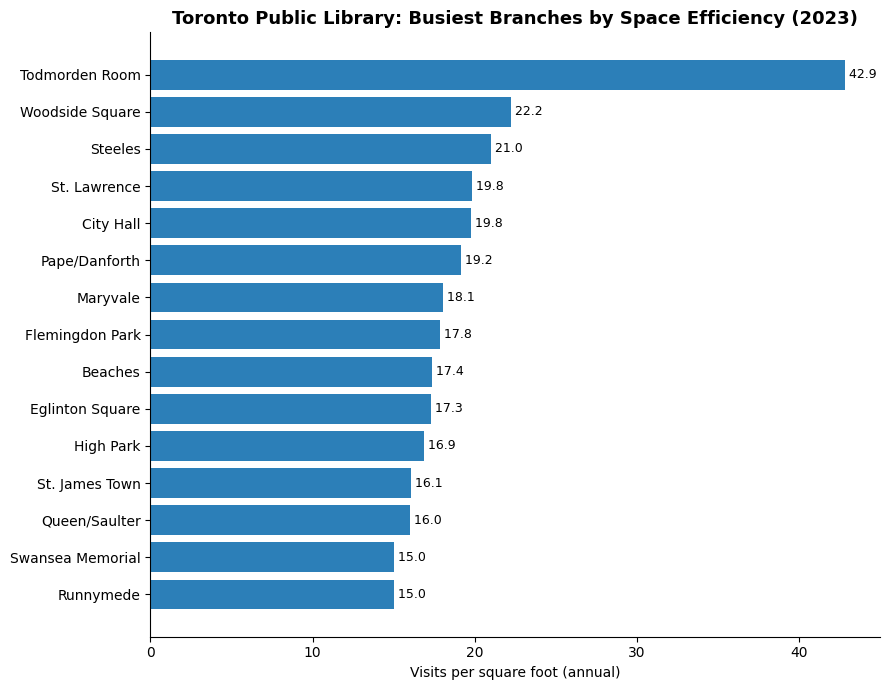

Saved figures/viz1_visits_per_sqft.png


In [8]:
# Compute usage intensity: visits per square foot (avoid divide-by-zero)
m1 = merged[merged[b_sqft] > 0].copy()
m1["visits_per_sqft"] = m1[v_visit] / m1[b_sqft]
top = m1.sort_values("visits_per_sqft", ascending=False).head(15).iloc[::-1]  # reverse for top-at-top

fig, ax = plt.subplots(figsize=(9, 7))
# Single accessible colour (ColorBrewer blue) — avoids rainbow/encoding-by-colour issues
bars = ax.barh(top[b_name], top["visits_per_sqft"], color="#2c7fb8")

ax.set_xlabel("Visits per square foot (annual)")
ax.set_title(f"Toronto Public Library: Busiest Branches by Space Efficiency ({latest_year})",
             fontsize=13, weight="bold")
ax.spines[["top", "right"]].set_visible(False)   # reduce chartjunk (data-ink ratio)

# Direct value labels so readers don't have to eyeball gridlines (accessibility)
for bar in bars:
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f" {bar.get_width():.1f}", va="center", fontsize=9)

fig.tight_layout()
fig.savefig(OUT / "viz1_visits_per_sqft.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/viz1_visits_per_sqft.png")

## 4. Visualization 2 — Does more space mean more visits?

**Chart type:** scatter plot of branch square footage vs. annual visits, with a fitted trend line. A scatter is the right encoding for showing the *relationship* between two continuous variables (and whether the "bigger = busier" assumption holds).

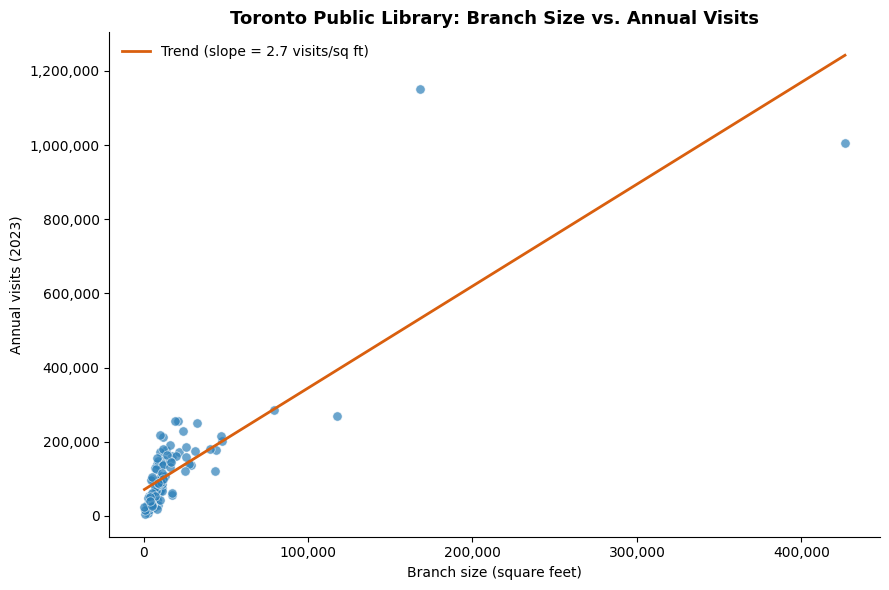

Saved figures/viz2_size_vs_visits.png
Correlation (r) = 0.839


In [9]:
m2 = merged[(merged[b_sqft] > 0) & (merged[v_visit] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(m2[b_sqft], m2[v_visit], s=45, alpha=0.7,
           color="#2c7fb8", edgecolor="white", linewidth=0.5)

# Least-squares trend line to summarize the relationship
x = m2[b_sqft].values
y = m2[v_visit].values
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, np.polyval(coef, xs), color="#d95f0e", linewidth=2,
        label=f"Trend (slope = {coef[0]:.1f} visits/sq ft)")

# Format axes with thousands separators (readability)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_xlabel("Branch size (square feet)")
ax.set_ylabel(f"Annual visits ({latest_year})")
ax.set_title("Toronto Public Library: Branch Size vs. Annual Visits",
             fontsize=13, weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(OUT / "viz2_size_vs_visits.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved figures/viz2_size_vs_visits.png")
print(f"Correlation (r) = {np.corrcoef(x, y)[0,1]:.3f}")

## 5. Reproducibility notes

- Data is fetched **live** from the City of Toronto CKAN API by dataset slug, not from a manually downloaded file — so re-running reproduces the pipeline end to end.
- Every transformation is in code and commented; no manual edits in a spreadsheet or image editor.
- Random seed is irrelevant here (no sampling) except in the clearly-marked synthetic fallback.
- Figures export at 300 dpi for print-quality submission.
- **Versioning caveat:** open datasets get refreshed. Record the date you ran this and the `latest_year` printed above, since the City may update or revise figures later.